In [18]:
import os
import xml.etree.ElementTree as ET
import random

DATA_DIR = "data"

def strip_ns(root):
    for elem in root.iter():
        if '}' in elem.tag:
            elem.tag = elem.tag.split('}', 1)[1]

print("🔍 DIAGNOSTIC DE LA LIAISON ACTEUR -> MANDAT -> ORGANE")

# 1. Lister tous les fichiers
fichiers_pa = []
fichiers_pm = []
fichiers_po = {}

for root_dir, dirs, files in os.walk(DATA_DIR):
    for f in files:
        path = os.path.join(root_dir, f)
        if f.startswith("PA") and f.endswith(".xml"): fichiers_pa.append(path)
        elif f.startswith("PM") and f.endswith(".xml"): fichiers_pm.append(path)
        elif f.startswith("PO") and f.endswith(".xml"): 
            uid = f.replace(".xml", "")
            fichiers_po[uid] = path

if not fichiers_pa:
    print("❌ Aucun acteur trouvé.")
    exit()

# 2. Choisir un acteur au hasard pour le test
acteur_test_path = random.choice(fichiers_pa)
acteur_id = os.path.basename(acteur_test_path).replace(".xml", "")

tree_pa = ET.parse(acteur_test_path)
root_pa = tree_pa.getroot(); strip_ns(root_pa)
prenom = root_pa.find(".//ident").findtext("prenom")
nom = root_pa.find(".//ident").findtext("nom")

print(f"\n👤 DÉPUTÉ TESTÉ : {prenom} {nom} ({acteur_id})")
print("-" * 50)

# 3. Chercher tous ses mandats (PM)
mandats_trouves = 0
mandats_gp = []

for pm_path in fichiers_pm:
    try:
        tree_pm = ET.parse(pm_path)
        root_pm = tree_pm.getroot(); strip_ns(root_pm)
        
        if root_pm.findtext("acteurRef") == acteur_id:
            mandats_trouves += 1
            type_org = root_pm.findtext("typeOrgane")
            
            # On ne garde que les Groupes Politiques
            if type_org == "GP":
                mandats_gp.append({
                    "pm_id": root_pm.findtext("uid"),
                    "po_ref": root_pm.find(".//organeRef").text if root_pm.find(".//organeRef") is not None else "Aucun",
                    "debut": root_pm.findtext("dateDebut"),
                    "fin": root_pm.findtext("dateFin"),
                    "legislature": root_pm.findtext("legislature")
                })
    except: continue

print(f"Total des mandats (tous types confondus) trouvés pour cet élu : {mandats_trouves}")

if not mandats_gp:
    print("❌ Aucun mandat de type 'GP' (Groupe Politique) trouvé pour cet élu.")
else:
    print(f"\n🏛️ MANDATS DE GROUPE POLITIQUE (GP) TROUVÉS : {len(mandats_gp)}")
    for m in mandats_gp:
        statut = "ACTIF" if not m['fin'] or m['fin'] == "None" or str(m['fin']).strip() == "" else f"Fini le {m['fin']}"
        print(f"\n  👉 Mandat {m['pm_id']} (Législature {m['legislature']})")
        print(f"     Période : {m['debut']} -> {statut}")
        print(f"     Organe pointé : {m['po_ref']}")
        
        # 4. Résolution du nom du parti (PO)
        if m['po_ref'] in fichiers_po:
            tree_po = ET.parse(fichiers_po[m['po_ref']])
            root_po = tree_po.getroot(); strip_ns(root_po)
            nom_parti = root_po.findtext("libelleAbrege") or root_po.findtext("libelle")
            print(f"     ✅ Traduction de l'organe : {nom_parti}")
        else:
            print(f"     ❌ Fichier organe {m['po_ref']}.xml introuvable dans data !")

print("\n" + "-" * 50)
print("Si le statut est 'ACTIF' et la traduction réussie, alors la mécanique fonctionne parfaitement.")

🔍 DIAGNOSTIC DE LA LIAISON ACTEUR -> MANDAT -> ORGANE

👤 DÉPUTÉ TESTÉ : Yannick Monnet (PA793174)
--------------------------------------------------
Total des mandats (tous types confondus) trouvés pour cet élu : 51

🏛️ MANDATS DE GROUPE POLITIQUE (GP) TROUVÉS : 3

  👉 Mandat PM796189 (Législature 16)
     Période : 2022-06-22 -> Fini le 2022-06-28
     Organe pointé : PO793087
     ✅ Traduction de l'organe : NI

  👉 Mandat PM800839 (Législature 16)
     Période : 2022-06-29 -> Fini le 2024-06-09
     Organe pointé : PO800502
     ✅ Traduction de l'organe : GDR - NUPES

  👉 Mandat PM842385 (Législature 17)
     Période : 2024-07-08 -> ACTIF
     Organe pointé : PO840056
     ✅ Traduction de l'organe : NI

--------------------------------------------------
Si le statut est 'ACTIF' et la traduction réussie, alors la mécanique fonctionne parfaitement.


In [73]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import unicodedata
import requests

# --- CONFIGURATION ---
CSV_BLOC = "bloc_bourgeois_final.csv"
CSV_INSEE = "FILO2021_DEC_COM.csv"
XML_ACTEURS = os.path.join("xml", "acteur")

# 1. Dictionnaire des départements (Nom -> Code)
DEP_MAP = {
    'ain': '01', 'aisne': '02', 'allier': '03', 'alpes de haute provence': '04', 'hautes alpes': '05',
    'alpes maritimes': '06', 'ardeche': '07', 'ardennes': '08', 'ariege': '09', 'aube': '10', 'aude': '11',
    'aveyron': '12', 'bouches du rhone': '13', 'calvados': '14', 'cantal': '15', 'charente': '16',
    'charente maritime': '17', 'cher': '18', 'correze': '19', 'corse du sud': '2A', 'haute corse': '2B',
    'cote d or': '21', 'cotes d armor': '22', 'creuse': '23', 'dordogne': '24', 'doubs': '25', 'drome': '26',
    'eure': '27', 'eure et loir': '28', 'finistere': '29', 'corse': '2B', 'gard': '30', 'haute garonne': '31',
    'gers': '32', 'gironde': '33', 'herault': '34', 'ille et vilaine': '35', 'indre': '36', 'indre et loire': '37',
    'isere': '38', 'jura': '39', 'landes': '40', 'loir et cher': '41', 'loire': '42', 'haute loire': '43',
    'loire atlantique': '44', 'loiret': '45', 'lot': '46', 'lot et garonne': '47', 'lozere': '48',
    'maine et loire': '49', 'manche': '50', 'marne': '51', 'haute marne': '52', 'mayenne': '53',
    'meurthe et moselle': '54', 'meuse': '55', 'morbihan': '56', 'moselle': '57', 'nievre': '58', 'nord': '59',
    'oise': '60', 'orne': '61', 'pas de calais': '62', 'puy de dome': '63', 'pyrenees atlantiques': '64',
    'hautes pyrenees': '65', 'pyrenees orientales': '66', 'bas rhin': '67', 'haut rhin': '68', 'rhone': '69',
    'haute saone': '70', 'saone et loire': '71', 'sarthe': '72', 'savoie': '73', 'haute savoie': '74',
    'paris': '75', 'seine maritime': '76', 'seine et marne': '77', 'yvelines': '78', 'deux sevres': '79',
    'somme': '80', 'tarn': '81', 'tarn et garonne': '82', 'var': '83', 'vaucluse': '84', 'vendee': '85',
    'vienne': '86', 'haute vienne': '87', 'vosges': '88', 'yonne': '89', 'territoire de belfort': '90',
    'essonne': '91', 'hauts de seine': '92', 'seine saint denis': '93', 'val de marne': '94', 'val d oise': '95',
    'guadeloupe': '971', 'martinique': '972', 'guyane': '973', 'la reunion': '974', 'reunion': '974', 'mayotte': '976'
}

# 2. Dictionnaire de secours pour les anciennes communes (fusionnées, mal orthographiées, ou dep absent/erroné dans le XML)
COMMUNES_FUSIONNEES = {
    # Fusionnées ou rebaptisées
    "cauderan_33": "33063",
    "malo les bains_59": "59183",
    "cherbourg_50": "50129",
    "boulogne billancourt_92": "92012",
    "carentan_50": "50099",
    "chaudron en mauges_49": "49244",
    "sainte gemmes d andigne_49": "49331",
    "parame saint malo_35": "35288",
    "rochefort sur mer_17": "17299",
    "domfront_61": "61145",
    "chalons sur marne_51": "51108",
    "chalons sur saone_71": "71076",
    "sarlat_24": "24520",
    "romorantin_41": "41194",
    "la bohalle_49": "49307",
    "saint yriex la perche_87": "87187",
    "evry_91": "91228",
    "juvisy_91": "91326",
    "buis sur damville_27": "27213",
    "saint pol sur mer_59": "59183",
    # DOM
    "saint denis reunion_974": "97411",
    "saint pierre de la reunion_974": "97416",
    "le port la reunion_974": "97407",
    "saint claude_971": "97124",
    # Dep absent dans le XML (clé sans code département : "{ville}_")
    "vichy_": "03310",
    "laon_": "02408",
    "chauny_": "02168",
    "moulins_": "03185",
    "villers semeuse_": "08469",
    "cagnes sur mer_": "06027",
    "saint quentin_": "02691",
    # Dep erroné dans le XML
    "pontoise_60": "95500",      # Pontoise est en Val-d'Oise (95), pas Oise (60)
    # Filet de sécurité
    "saint adresse_76": "76559",
}

def normalize(s):
    if not s or str(s) == "nan": return ""
    s = unicodedata.normalize('NFKD', str(s)).encode('ASCII', 'ignore').decode('utf-8')
    s = s.lower().replace("-", " ").replace("'", " ")
    s = s.replace("st ", "saint ").replace("ste ", "sainte ")
    if s.startswith("paris "): return "paris"
    if s.startswith("lyon "): return "lyon"
    if s.startswith("marseille "): return "marseille"
    return s.strip()

def strip_ns(root):
    for elem in root.iter():
        if '}' in elem.tag: elem.tag = elem.tag.split('}', 1)[1]

# --- CHARGEMENT ---
print("📡 Téléchargement du dictionnaire des communes (API Gouv)...")
communes_api = requests.get("https://geo.api.gouv.fr/communes?fields=nom,code,codeDepartement").json()
dict_villes = {f"{normalize(c.get('nom'))}_{c.get('codeDepartement', '')}": c.get('code') for c in communes_api}
dict_villes.update(COMMUNES_FUSIONNEES)

print("📂 Lecture du fichier FILO2021 (Revenus)...")
df_insee = pd.read_csv(CSV_INSEE, sep=";", usecols=['CODGEO', 'Q221'], dtype={'CODGEO': str})
dict_revenus = df_insee.set_index('CODGEO')['Q221'].to_dict()

print("👥 Lecture des 577 députés du Bloc Bourgeois...")
df_bloc = pd.read_csv(CSV_BLOC)

# --- ANALYSE ---
resultats = []
echecs_actuels = []

for _, row in df_bloc.iterrows():
    pa_id = row['pa_id']
    nom_depute = row['député']
    xml_path = os.path.join(XML_ACTEURS, f"{pa_id}.xml")

    ville = "Inconnue"
    revenu_heritage = "NaN"
    pays = "France"

    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot(); strip_ns(root)

        info_nais = root.find(".//infoNaissance")
        if info_nais is not None:
            pays = info_nais.findtext("paysNais")
            ville = info_nais.findtext("villeNais") or ""
            dep_nom = info_nais.findtext("depNais") or ""

            # pays=None ou vide → on considère France (données manquantes dans le XML)
            pays_est_france = not pays or pays.lower() == "france"

            if pays_est_france and ville:
                ville_norm = normalize(ville)
                code_dep = DEP_MAP.get(normalize(dep_nom)) if dep_nom else None

                # Clé de recherche : avec dept si connu, sans sinon (fallback "_")
                cle_recherche = f"{ville_norm}_{code_dep}" if code_dep else f"{ville_norm}_"
                code_insee = dict_villes.get(cle_recherche)

                if code_insee:
                    revenu = dict_revenus.get(code_insee)
                    if revenu and not pd.isna(revenu):
                        revenu_heritage = revenu
                    else:
                        echecs_actuels.append(f"{nom_depute} : {ville} ({code_dep or '?'}) -> Pas de revenu INSEE (code {code_insee})")
                else:
                    echecs_actuels.append(f"{nom_depute} : {ville} ({code_dep or '?'}) -> Commune introuvable")

    row_dict = row.to_dict()
    row_dict["ville_naissance"] = ville
    row_dict["pays_naissance"] = pays
    row_dict["revenu_commune_naissance"] = revenu_heritage
    resultats.append(row_dict)

# --- EXPORT ---
df_final = pd.DataFrame(resultats)
df_final.to_csv("bloc_bourgeois_heritage_final.csv", index=False, encoding="utf-8")

nb_etranger = len(df_final[df_final["pays_naissance"].notna() & (df_final["pays_naissance"].str.lower() != "france")])
nb_succes = len(df_final[df_final["revenu_commune_naissance"] != "NaN"])

print("\n" + "="*40)
print(f"🎉 Fichier 'bloc_bourgeois_heritage_final.csv' créé !")
print(f"   - Match réussi : {nb_succes}")
print(f"   - Nés à l'étranger : {nb_etranger} (NaN attendus)")
print("="*40)

if echecs_actuels:
    print(f"\n⚠️ {len(echecs_actuels)} échecs restants :")
    for e in echecs_actuels:
        print("  -", e)

📡 Téléchargement du dictionnaire des communes (API Gouv)...
📂 Lecture du fichier FILO2021 (Revenus)...
👥 Lecture des 577 députés du Bloc Bourgeois...

🎉 Fichier 'bloc_bourgeois_heritage_final.csv' créé !
   - Match réussi : 535
   - Nés à l'étranger : 30 (NaN attendus)

⚠️ 16 échecs restants :
  - Christian Baptiste : Pointe-à-Pitre (971) -> Pas de revenu INSEE (code 97120)
  - Olivier Serva : Pointe-à-Pitre (971) -> Pas de revenu INSEE (code 97120)
  - Max Mathiasin : Deshaies (971) -> Pas de revenu INSEE (code 97111)
  - Nicolas Metzdorf : Nouméa (?) -> Commune introuvable
  - Mereana Reid Arbelot : Papeete (?) -> Commune introuvable
  - Stéphane Lenormand : Saint-Pierre-et-Miquelon (?) -> Commune introuvable
  - Frantz Gumbs : Saint-Martin (971) -> Commune introuvable
  - Nathalie Coggia : France (78) -> Commune introuvable
  - Elie Califer : St Claude (971) -> Pas de revenu INSEE (code 97124)
  - Jean-Victor Castor : Sinnamary (973) -> Pas de revenu INSEE (code 97312)
  - Davy Rima

In [75]:
# ══════════════════════════════════════════════════════════════════════════════
# RECALCUL DE L'ANCIENNETÉ PONDÉRÉE
# ══════════════════════════════════════════════════════════════════════════════
# Problèmes de l'ancien calcul :
#   1. PRESREP non compté (ex: Hollande perd 5 ans de présidence)
#   2. GOUVERNEMENT + MINISTERE doublement comptés (même périodes)
#   3. Pas de distinction Premier ministre / Ministre / Secrétaire d'État
#   4. Pas de bonus pour leadership (Président AN, de groupe, de commission)
#   5. dateFin nil → datetime.now() au lieu de DATE_REF
#
# Nouveau scoring :
#   ASSEMBLEE / SENAT         : ×1.0  (base)
#   PRESREP                   : ×3.0
#   Premier ministre           : ×2.5
#   Ministre d'État            : ×2.0
#   Ministre / Garde des sceaux: ×1.5
#   Ministre délégué           : ×1.3
#   Secrétaire d'État          : ×1.2
#   en mission / autre MINISTERE: ×1.0
#   GOUVERNEMENT               : ignoré (doublon de MINISTERE)
#   Président de l'AN (CONFPT) : bonus +0.5/an
#   Président groupe/commission: bonus +0.3/an
#   Vice-Président commission  : bonus +0.1/an
# ══════════════════════════════════════════════════════════════════════════════

import os, xml.etree.ElementTree as ET, pandas as pd
from datetime import datetime

CSV_PATH = "bloc_bourgeois_heritage_final.csv"
XML_ACTEURS = os.path.join("xml", "acteur")
DATE_REF = datetime(2024, 6, 9)  # dissolution

# ── Poids ────────────────────────────────────────────────────────────────────
POIDS_BASE = {"ASSEMBLEE": 1.0, "SENAT": 1.0, "PRESREP": 3.0}

POIDS_MINISTERE = {
    "Premier ministre": 2.5, "Première ministre": 2.5,
    "Ministre d'État": 2.0, "Ministre d'état": 2.0,
    "Garde des sceaux": 1.5,
    "Ministre": 1.5,
    "Ministre délégué": 1.3, "Ministre déléguée": 1.3,
    "Secrétaire d'État": 1.2, "Secrétaire d'état": 1.2,
    "Haut-commissaire": 1.2,
    "en mission": 1.0,
}
POIDS_MINISTERE_DEFAULT = 1.2

BONUS_LEADERSHIP = {
    "CONFPT":  {"président": 0.5},
    "COMPER":  {"président": 0.3, "vice-président": 0.1},
    "GP":      {"président": 0.3},
}

def strip_ns(root):
    for elem in root.iter():
        if '}' in elem.tag:
            elem.tag = elem.tag.split('}', 1)[1]

def get_days(d_deb, d_fin):
    try:
        start = datetime.strptime(d_deb, "%Y-%m-%d")
        if d_fin and d_fin.strip() and d_fin.strip() != "None":
            end = datetime.strptime(d_fin.strip(), "%Y-%m-%d")
        else:
            end = DATE_REF
        return max(0, (end - start).days)
    except:
        return 0

def compute_score(pa_id):
    xml_path = os.path.join(XML_ACTEURS, f"{pa_id}.xml")
    if not os.path.exists(xml_path):
        return None
    tree = ET.parse(xml_path)
    root = tree.getroot()
    strip_ns(root)

    # Collecter mandats
    mandats = []
    for m in root.findall(".//mandat"):
        t = m.findtext("typeOrgane") or ""
        d_deb = m.findtext("dateDebut") or ""
        d_fin_raw = m.findtext("dateFin")
        d_fin = d_fin_raw if d_fin_raw and d_fin_raw.strip() else None
        qualite = m.findtext(".//codeQualite") or ""
        mandats.append((t, d_deb, d_fin, qualite))

    # Déduplication PRESREP (même dateDebut → garder celui avec dateFin)
    presrep_best = {}
    for t, d_deb, d_fin, q in mandats:
        if t == "PRESREP":
            if d_deb not in presrep_best or (d_fin and not presrep_best[d_deb]):
                presrep_best[d_deb] = d_fin

    score_jours = 0.0
    presrep_used = set()

    for t, d_deb, d_fin, qualite in mandats:
        if t in POIDS_BASE:
            if t == "PRESREP":
                if d_deb in presrep_used:
                    continue
                presrep_used.add(d_deb)
                d_fin = presrep_best[d_deb]
            score_jours += get_days(d_deb, d_fin) * POIDS_BASE[t]

        elif t == "MINISTERE":
            poids = POIDS_MINISTERE.get(qualite, POIDS_MINISTERE_DEFAULT)
            score_jours += get_days(d_deb, d_fin) * poids

        elif t == "GOUVERNEMENT":
            pass  # ignoré (doublon de MINISTERE)

        elif t in BONUS_LEADERSHIP:
            bonus_map = BONUS_LEADERSHIP[t]
            q_lower = qualite.lower()
            for label, bonus in bonus_map.items():
                if label in q_lower:
                    score_jours += get_days(d_deb, d_fin) * bonus
                    break

    return round(score_jours / 365.25, 4) if score_jours > 0 else 0.0


# ── Recalcul ─────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
ancien = df['anciennete'].copy()

scores = {}
for pa_id in df['pa_id']:
    s = compute_score(pa_id)
    if s is not None:
        scores[pa_id] = s

df['anciennete'] = df['pa_id'].map(scores).fillna(df['anciennete'])

# ── Comparaison ──────────────────────────────────────────────────────────────
delta = df['anciennete'] - ancien
changed = df[delta.abs() > 0.5].copy()
changed['_delta'] = delta[changed.index]
changed = changed.sort_values('_delta', ascending=False)

print(f"Recalcul ancienneté pondérée : {len(scores)} députés traités")
print(f"{len(changed)} avec changement > 0.5 an\n")
print(f"{'Député':<30s} {'Avant':>7s} {'Après':>7s} {'Delta':>7s}")
print("-" * 55)
for _, r in changed.head(25).iterrows():
    a = ancien[r.name]
    print(f"{r['député']:<30s} {a:7.1f} {r['anciennete']:7.1f} {r['_delta']:+7.1f}")
if len(changed) > 25:
    print(f"  ... et {len(changed)-25} autres")

# Cas spécifiques
for nom in ["François Hollande", "Gabriel Attal", "Yaël Braun-Pivet",
            "Michel Barnier", "Élisabeth Borne", "Marine Le Pen"]:
    row = df[df['député'] == nom]
    if len(row):
        r = row.iloc[0]
        a = ancien[r.name]
        print(f"\n  {nom}: {a:.1f} -> {r['anciennete']:.1f} ({r['anciennete']-a:+.1f})")

# Sauvegarde
df.to_csv(CSV_PATH, index=False, encoding="utf-8")
print(f"\n'{CSV_PATH}' mis à jour.")
print(f"Médiane: {df['anciennete'].median():.1f} | Moyenne: {df['anciennete'].mean():.1f} | Max: {df['anciennete'].max():.1f}")


Recalcul ancienneté pondérée : 577 députés traités
0 avec changement > 0.5 an

Député                           Avant   Après   Delta
-------------------------------------------------------

  François Hollande: 24.9 -> 24.9 (+0.0)

  Gabriel Attal: 9.0 -> 9.0 (+0.0)

  Yaël Braun-Pivet: 9.6 -> 9.6 (+0.0)

  Michel Barnier: 3.0 -> 3.0 (+0.0)

  Élisabeth Borne: 13.7 -> 13.7 (+0.0)

  Marine Le Pen: 7.6 -> 7.6 (+0.0)

'bloc_bourgeois_heritage_final.csv' mis à jour.
Médiane: 2.0 | Moyenne: 3.9 | Max: 31.6


In [76]:
# ══════════════════════════════════════════════════════════════════════════════
# RECALCUL DES CODES PCS
# Corrige le bug de l'ancien script qui mappait incorrectement des actifs
# à code 74 (Ancien cadre = retraité).
# Source : catSocPro + libelleCourant dans xml/acteur/PA*.xml
# ══════════════════════════════════════════════════════════════════════════════
import os, xml.etree.ElementTree as ET, pandas as pd

CSV_PATH   = "bloc_bourgeois_heritage_final.csv"
XML_ACTEURS = os.path.join("xml", "acteur")

# Mapping direct catSocPro → (code, libelle)
CAT_PCS = {
    "Agriculteurs exploitants":                 (12, "Agriculteur sur moyenne exploitation"),
    "Artisans":                                 (21, "Artisan"),
    "Commerçants et assimilés":                 (22, "Commerçant et assimilé"),
    "Chefs d'entreprise de 10 salariés ou plus":(23, "Chef d'entreprise de 10 salariés ou plus"),
    "Chefs d'entreprise de plus de 10 personnes":(23,"Chef d'entreprise de 10 salariés ou plus"),
    "Professions libérales":                    (31, "Profession libérale"),
    "Professions libérales et assimilés":       (31, "Profession libérale"),
    "Cadres administratifs et techniques de la fonction publique": (33, "Cadre de la fonction publique"),
    "Ingénieurs et cadres techniques d'entreprise": (38, "Ingénieur et cadre technique d'entreprise"),
    "Professeurs et professions scientifiques supérieures": (34, "Professeur, profession scientifique"),
    "Professions de l'enseignement primaire et professionnel, de la formation continue et du sport":
                                                (42, "Professeur des écoles, instituteur et assimilé"),
    "Professions intermédiaires de l'enseignement, de la santé, de la fonction publique et assimilés":
                                                (43, "Profession intermédiaire de la santé et du travail social"),
    "Professions intermédiaires administratives et commerciales des entreprises":
                                                (46, "Profession intermédiaire administrative et commerciale des entreprises"),
    "Agents de maîtrise (hors maîtrise administrative)": (48, "Contremaître, agent de maîtrise"),
    "Contremaîtres, agents de maîtrise":        (48, "Contremaître, agent de maîtrise"),
    "Techniciens":                              (47, "Technicien"),
    "Employés de la fonction publique":         (52, "Employé civil et agent de service de la fonction publique"),
    "Employés administratifs de la fonction publique, agents de service et auxiliaires de santé":
                                                (52, "Employé civil et agent de service de la fonction publique"),
    "Employés administratifs d'entreprise":     (54, "Employé administratif d'entreprise"),
    "Employés de commerce":                     (55, "Employé de commerce"),
    "Personnels des services directs aux particuliers": (56, "Personnel des services directs aux particuliers"),
    "Ouvriers qualifiés":                       (62, "Ouvrier qualifié"),
    "Ouvriers qualifiés de type industriel":    (62, "Ouvrier qualifié de type industriel"),
    "Ouvriers non qualifiés":                   (67, "Ouvrier non qualifié"),
    "Ouvriers agricoles":                       (69, "Ouvrier agricole"),
    "Anciens cadres et professions intermédiaires": (74, "Ancien cadre"),
    "Anciens artisans, commerçants, chefs d'entreprise": (72, "Ancien artisan, commerçant, chef d'entreprise"),
    "Anciens employés et ouvriers":             (77, "Ancien employé ou ouvrier"),
    "Inactifs divers (autres que retraités)":   (85, "Personne diverse sans activité professionnelle de moins de 60 ans (sauf retraité)"),
    "Sans profession déclarée":                 (0,  "Non classé"),
}

# Mots-clés pour affiner les catégories ambiguës
KW_INFO_ARTS = ["journaliste", "journalist", "information", "arts", "spectacle",
                "cinéma", "photo", "acteur", "réalisat", "auteur"]
KW_PROF_SCI  = ["professeur", "enseignant", "chercheur", "researcher", "universitaire",
                "maître de conférence", "directeur de recherche", "inspecteur de l'éducation"]
KW_INGENIEUR = ["ingénieur", "ingenieur", "technique", "informatique", "r&d",
                "chef de projet", "data", "systèmes", "techni"]

def strip_ns(root):
    for e in root.iter():
        if "}" in e.tag:
            e.tag = e.tag.split("}", 1)[1]

def get_pcs(pa_id):
    xml_path = os.path.join(XML_ACTEURS, f"{pa_id}.xml")
    if not os.path.exists(xml_path):
        return (0, "Non classé")
    tree = ET.parse(xml_path)
    root = tree.getroot(); strip_ns(root)
    prof = root.find(".//profession")
    if prof is None:
        return (0, "Non classé")
    lc  = (prof.findtext("libelleCourant") or "").strip()
    cat_el = prof.find(".//catSocPro")
    cat = cat_el.text.strip() if cat_el is not None and cat_el.text else ""
    lc_low = lc.lower()

    # Détecter code direct dans libelleCourant type "(74) - Ancien cadre"
    if lc.startswith("(") and ") -" in lc:
        try:
            code    = int(lc[1:lc.index(")")])
            libelle = lc[lc.index(") -") + 3:].strip()
            return (code, libelle)
        except Exception:
            pass

    # Catégories nécessitant un raffinement par libelleCourant
    if "Cadres de la fonction publique" in cat:
        if any(k in lc_low for k in KW_INFO_ARTS):
            return (35, "Profession de l'information, des arts et des spectacles")
        if any(k in lc_low for k in KW_PROF_SCI):
            return (34, "Professeur, profession scientifique")
        return (33, "Cadre de la fonction publique")

    if "Cadres des services administratifs et commerciaux" in cat:
        return (37, "Cadre administratif et commercial d'entreprise")

    if "Cadres d'entreprise" in cat:
        if any(k in lc_low for k in KW_INGENIEUR):
            return (38, "Ingénieur et cadre technique d'entreprise")
        return (37, "Cadre administratif et commercial d'entreprise")

    return CAT_PCS.get(cat, (0, "Non classé"))

df = pd.read_csv(CSV_PATH)
changed = []
for i, row in df.iterrows():
    new_code, new_lib = get_pcs(row["pa_id"])
    old_code = row["code_pcs"]
    if new_code != old_code:
        changed.append(f"  {row['député']}: {int(old_code)} → {new_code} ({new_lib})")
    df.at[i, "code_pcs"]    = new_code
    df.at[i, "libelle_pcs"] = new_lib

print(f"{len(changed)} codes PCS corrigés :")
for c in changed:
    print(c)

df.to_csv(CSV_PATH, index=False)
print("\nCSV mis à jour.")


0 codes PCS corrigés :

CSV mis à jour.


In [ ]:
# Reconstruit bloc_bourgeois_final.csv depuis le CSV héritage
# (à exécuter après les cellules de correction ancienneté + PCS)
import pandas as pd

df_heritage = pd.read_csv('bloc_bourgeois_heritage_final.csv')
df_heritage[['pa_id', 'député', 'groupe_politique', 'anciennete', 'code_pcs', 'libelle_pcs']]\
    .to_csv('bloc_bourgeois_final.csv', index=False)
print(f"bloc_bourgeois_final.csv recréé ({len(df_heritage)} lignes)")


,pa_id,député,groupe_politique,anciennete,code_pcs,libelle_pcs,ville_naissance,pays_naissance,revenu_commune_naissance
0,PA1008,Alain David,SOC,7.2682,38,Ingénieur et cadre technique d'entreprise,Libourne,France,20130.0
1,PA1567,Jérôme Guedj,SOC,9.3361,33,Cadre de la fonction publique,Pantin,France,18580.0
2,PA1592,David Habib,LIOT,22.2078,37,Cadre administratif et commercial d'entreprise,Paris,France,31670.0
3,PA1630,Michel Herbillon,DR,26.0608,37,Cadre administratif et commercial d'entreprise,Saint-Mandé,France,40330.0
4,PA1654,François Hollande,SOC,24.8898,33,Cadre de la fonction publique,Rouen,NaN,20870.0


C:\Users\vbecquet\AppData\Local\Temp\ipykernel_19020\3215150448.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




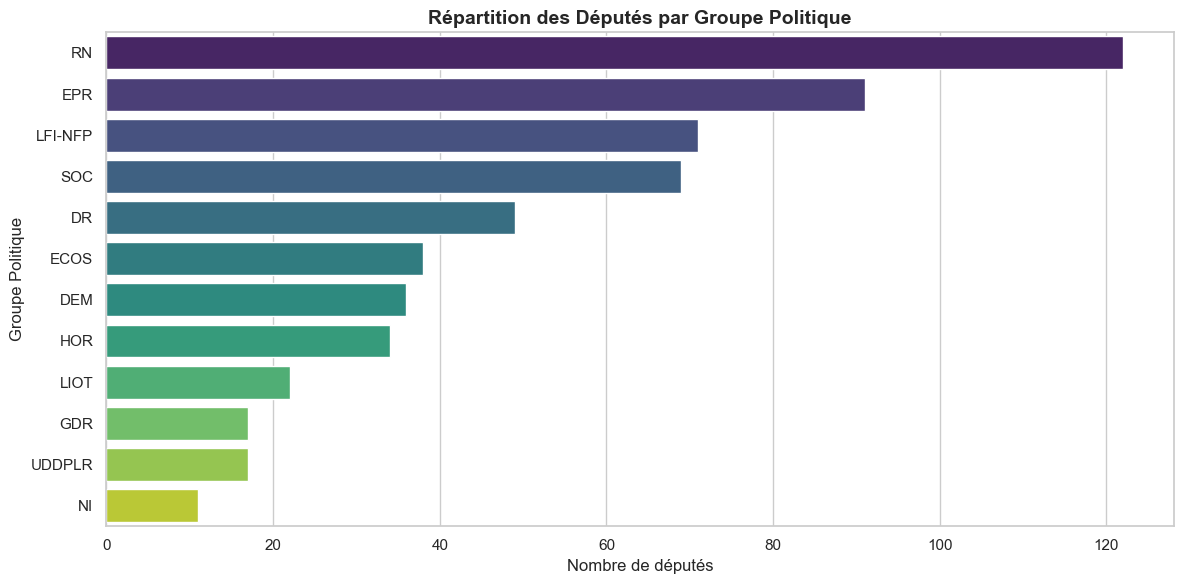

C:\Users\vbecquet\AppData\Local\Temp\ipykernel_19020\3215150448.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




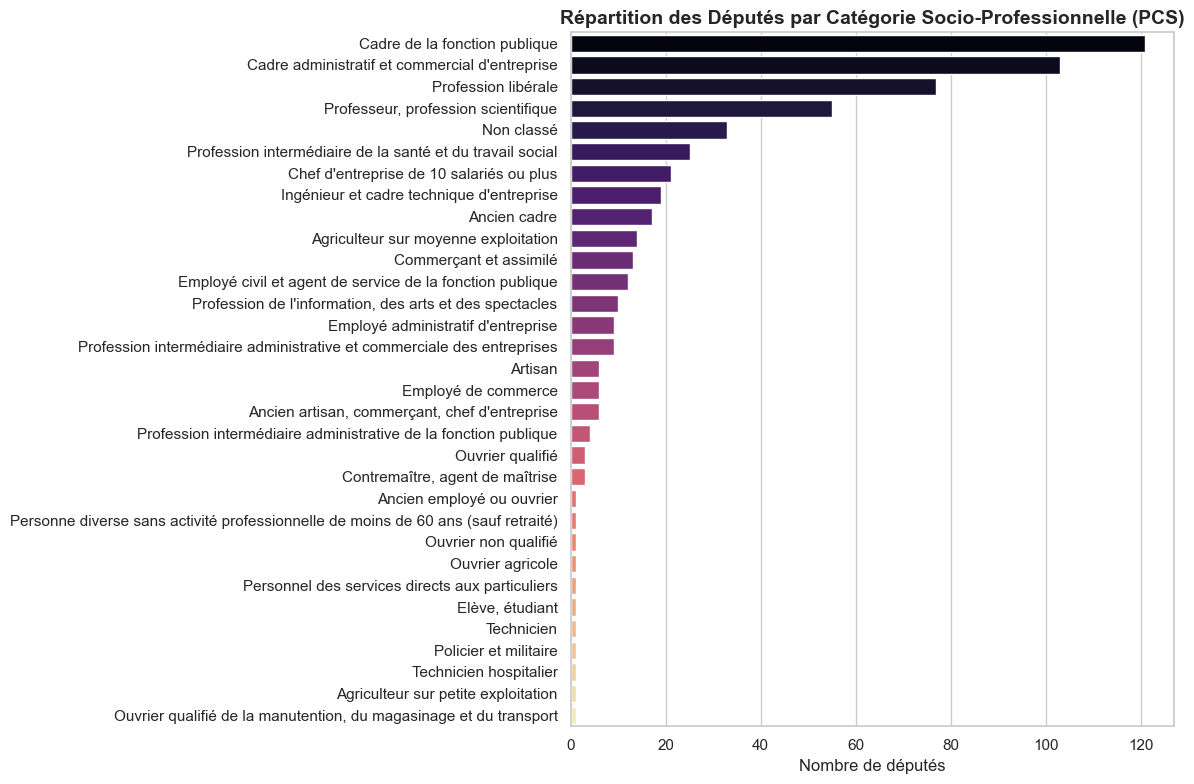

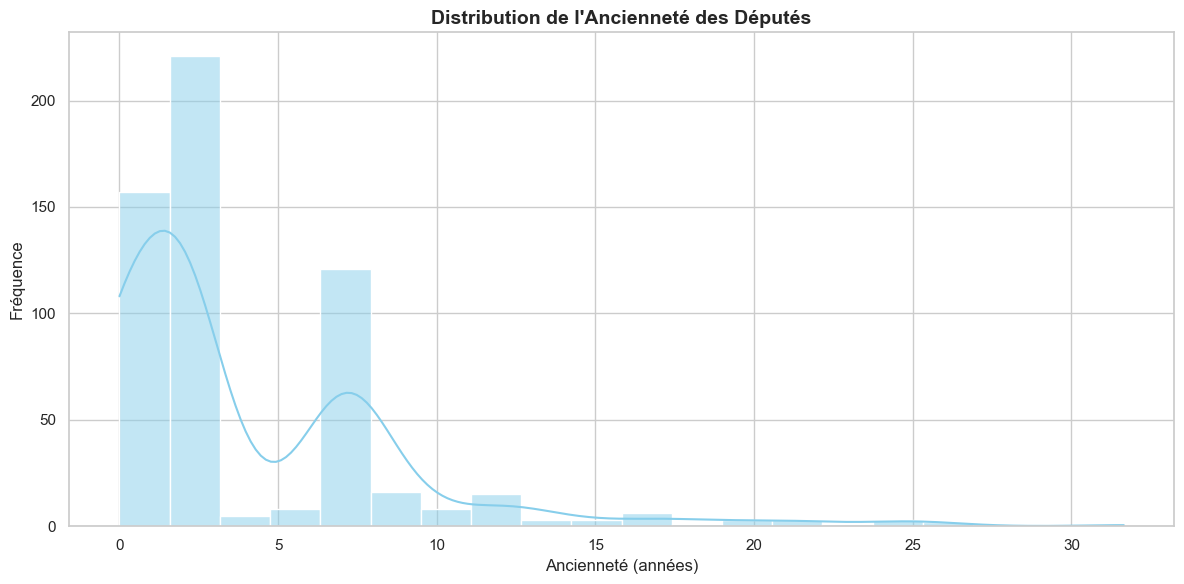

In [77]:
bloc = pd.read_csv("bloc_bourgeois_heritage_final.csv")
display(bloc.head())
# Barplot of political groups
plt.figure(figsize=(12, 6))
groupe_counts = bloc['groupe_politique'].value_counts()
sns.barplot(y=groupe_counts.index, x=groupe_counts.values, palette='viridis')
plt.title("Répartition des Députés par Groupe Politique", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de députés")
plt.ylabel("Groupe Politique")
plt.tight_layout()
plt.show()

# Barplot of PCS distribution
plt.figure(figsize=(12, 8))
pcs_counts = bloc['libelle_pcs'].value_counts()
sns.barplot(y=pcs_counts.index, x=pcs_counts.values, palette='magma')
plt.title("Répartition des Députés par Catégorie Socio-Professionnelle (PCS)", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de députés")
plt.ylabel("")
plt.tight_layout()
# Histogram of seniority (anciennete)
plt.figure(figsize=(12, 6))
sns.histplot(bloc['anciennete'].dropna(), bins=20, kde=True, color='skyblue')
plt.title("Distribution de l'Ancienneté des Députés", fontsize=14, fontweight='bold')
plt.xlabel("Ancienneté (années)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

In [79]:
import xml.etree.ElementTree as ET
from pathlib import Path
from html import unescape
import textwrap

# ─────────────────────────────────────────────────────────────────────────────
# FICHE COMPLÈTE D'UN ÉLU  — renseigner le numéro PA ci-dessous
# ─────────────────────────────────────────────────────────────────────────────
PA = "PA1654"   # ← François Hollande  (changer ici)
PA = "PA722190" # Attal
PA = "PA227089" 
BASE = Path(".")
NS   = "http://schemas.assemblee-nationale.fr/referentiel"

def tx(el, tag):
    """Texte d'un sous-élément, None si absent ou xsi:nil."""
    if el is None: return None
    child = el.find(f"{{{NS}}}{tag}")
    if child is None: return None
    if child.get("{http://www.w3.org/2001/XMLSchema-instance}nil") == "true": return None
    return (child.text or "").strip() or None

def load_organe(organe_ref):
    """Charge un fichier organe et retourne son libellé + dates."""
    path = BASE / "xml" / "organe" / f"{organe_ref}.xml"
    if not path.exists():
        path = BASE / "data" / "organe" / f"{organe_ref}.xml"
    if not path.exists():
        return {"libelle": organe_ref, "debut": None, "fin": None}
    root = ET.parse(path).getroot()
    vimode = root.find(f"{{{NS}}}viMoDe")
    return {
        "libelle": tx(root, "libelle") or tx(root, "libelleAbrege") or organe_ref,
        "debut":   tx(vimode, "dateDebut") if vimode is not None else None,
        "fin":     tx(vimode, "dateFin")   if vimode is not None else None,
        "type":    tx(root, "codeType"),
    }

# ─── Chargement du fichier acteur ────────────────────────────────────────────
acteur_path = BASE / "xml" / "acteur" / f"{PA}.xml"
if not acteur_path.exists():
    acteur_path = BASE / "data" / "acteur" / f"{PA}.xml"
if not acteur_path.exists():
    raise FileNotFoundError(f"Aucun fichier trouvé pour {PA}")

root = ET.parse(acteur_path).getroot()

# ─── État civil ──────────────────────────────────────────────────────────────
ident      = root.find(f"{{{NS}}}etatCivil/{{{NS}}}ident")
naissance  = root.find(f"{{{NS}}}etatCivil/{{{NS}}}infoNaissance")
profession = root.find(f"{{{NS}}}profession")

civ    = tx(ident, "civ") or ""
prenom = tx(ident, "prenom") or ""
nom    = tx(ident, "nom") or ""
trig   = tx(ident, "trigramme")
deces  = tx(root.find(f"{{{NS}}}etatCivil"), "dateDeces")

date_nais  = tx(naissance, "dateNais")
ville_nais = tx(naissance, "villeNais")
dep_nais   = tx(naissance, "depNais")
pays_nais  = tx(naissance, "paysNais")

prof_libelle = tx(profession, "libelleCourant")
soc          = profession.find(f"{{{NS}}}socProcINSEE") if profession is not None else None
cat_soc      = tx(soc, "catSocPro")
fam_soc      = tx(soc, "famSocPro")

# ─── Adresses ────────────────────────────────────────────────────────────────
TYPE_ADRESSE = {
    "0": "Adresse officielle", "2": "Adresse de permanence",
    "11": "Téléphone", "14": "Télécopie", "15": "Courriel",
    "22": "Site internet", "23": "Site Sénat", "24": "Twitter/X",
    "25": "Facebook", "29": "Instagram", "30": "LinkedIn",
}

adresses = []
for adr in root.findall(f"{{{NS}}}adresses/{{{NS}}}adresse"):
    type_code = tx(adr, "type") or ""
    type_lbl  = TYPE_ADRESSE.get(type_code, tx(adr, "typeLibelle") or type_code)
    # Valeur : email/web/tel
    valeur = tx(adr, "valElec") or tx(adr, "valVoice")
    if valeur is None:
        # Adresse postale
        parts = filter(None, [
            tx(adr, "intitule"), tx(adr, "numeroRue"), tx(adr, "nomRue"),
            tx(adr, "complementAdresse"),
            (tx(adr, "codePostal") or "") + " " + (tx(adr, "ville") or ""),
        ])
        valeur = ", ".join(p.strip() for p in parts if p.strip())
    adresses.append((type_lbl, valeur))

# ─── Mandats ─────────────────────────────────────────────────────────────────
TYPE_ORGANE_LBL = {
    "ASSEMBLEE":  "Député à l'Assemblée nationale",
    "SENAT":      "Sénateur",
    "GP":         "Groupe parlementaire",
    "COMPER":     "Commission permanente",
    "COMSPEC":    "Commission spéciale",
    "COMPARL":    "Commission parlementaire",
    "DELEGBUR":   "Délégation / Bureau",
    "MISINFO":    "Mission d'information",
    "CONFINTER":  "Conférence interpar.",
    "PRESREP":    "Président de la République",
    "GVTL":       "Gouvernement (local)",
    "GVT":        "Gouvernement",
    "OFFPAR":     "Office parlementaire",
    "CMP":        "Commission mixte paritaire",
    "CAUCUS":     "Caucus",
}

mandats_parsed = []
for m in root.findall(f"{{{NS}}}mandats/{{{NS}}}mandat"):
    type_org   = tx(m, "typeOrgane") or ""
    date_debut = tx(m, "dateDebut")
    date_fin   = tx(m, "dateFin")
    leg        = tx(m, "legislature")
    qualite    = tx(m.find(f"{{{NS}}}infosQualite"), "libQualite") or ""
    organe_refs = [o.text for o in m.findall(f"{{{NS}}}organes/{{{NS}}}organeRef") if o.text]

    # Infos supplémentaires pour mandats parlementaires
    election = m.find(f"{{{NS}}}election")
    lieu = election.find(f"{{{NS}}}lieu") if election is not None else None
    cause_mandat  = tx(election, "causeMandat") if election is not None else None
    dep_election  = tx(lieu, "departement") if lieu is not None else None
    num_dep       = tx(lieu, "numDepartement") if lieu is not None else None
    num_circo     = tx(lieu, "numCirco") if lieu is not None else None
    mandature     = m.find(f"{{{NS}}}mandature")
    cause_fin     = tx(mandature, "causeFin") if mandature is not None else None
    prem_election = tx(mandature, "premiereElection") if mandature is not None else None

    # Suppléant(s)
    suppleants = [s.find(f"{{{NS}}}suppleantRef").text
                  for s in m.findall(f"{{{NS}}}suppleants/{{{NS}}}suppleant")
                  if s.find(f"{{{NS}}}suppleantRef") is not None
                  and s.find(f"{{{NS}}}suppleantRef").text]

    organes_info = [load_organe(ref) for ref in organe_refs]

    mandats_parsed.append({
        "type": type_org, "type_lbl": TYPE_ORGANE_LBL.get(type_org, type_org),
        "qualite": qualite, "legislature": leg,
        "debut": date_debut, "fin": date_fin,
        "organes": organes_info,
        "departement": f"{dep_election} ({num_dep})" if dep_election else None,
        "circo": num_circo, "cause_mandat": cause_mandat, "cause_fin": cause_fin,
        "premiere": prem_election == "1",
        "suppleants": suppleants,
    })

# Trier par date de début
mandats_parsed.sort(key=lambda x: x["debut"] or "0000")

# ─── Déclarations de déport ──────────────────────────────────────────────────
deport_dir = BASE / "xml" / "deport"
deports = []
for f in sorted(deport_dir.glob(f"*{PA}*.xml")):
    dr = ET.parse(f).getroot()
    portee   = dr.find(f"{{{NS}}}portee")
    instance = dr.find(f"{{{NS}}}instance")
    cible    = dr.find(f"{{{NS}}}cible")
    expl_raw = tx(dr, "explication") or ""
    explication = unescape(expl_raw).replace("<p>","").replace("</p>","").replace("<br>","").replace("<br/>","").strip()
    deports.append({
        "date":       tx(dr, "datePublication"),
        "portee":     tx(portee, "libelle") if portee is not None else None,
        "instance":   tx(instance, "libelle") if instance is not None else None,
        "reference":  tx(cible.find(f"{{{NS}}}type") if cible is not None else None, "libelle"),
        "texte":      tx(cible, "referenceTextuelle") if cible is not None else None,
        "explication": explication,
    })

# ─────────────────────────────────────────────────────────────────────────────
# AFFICHAGE
# ─────────────────────────────────────────────────────────────────────────────
SEP  = "─" * 70
SEP2 = "· " * 35

def fmt_date(d):
    if not d: return "—"
    try: return f"{d[8:10]}/{d[5:7]}/{d[:4]}"
    except: return d

print(f"\n{'═'*70}")
print(f"  FICHE PARLEMENTAIRE — {civ} {prenom.upper()} {nom.upper()}  [{PA}]")
print(f"{'═'*70}")

# État civil
print(f"\n▌ ÉTAT CIVIL")
print(f"  Né{' ' if civ=='M.' else 'e'} le  : {fmt_date(date_nais)}")
lieu_nais = ", ".join(filter(None, [ville_nais, dep_nais, pays_nais]))
if lieu_nais: print(f"  Lieu     : {lieu_nais}")
if trig:      print(f"  Trigramme: {trig}")
if deces:     print(f"  Décès    : {fmt_date(deces)}")

# Profession
print(f"\n▌ PROFESSION")
if prof_libelle: print(f"  {prof_libelle}")
if cat_soc:      print(f"  Catégorie INSEE : {cat_soc}")
if fam_soc:      print(f"  Famille INSEE   : {fam_soc}")

# Adresses / contacts
if adresses:
    print(f"\n▌ COORDONNÉES")
    for lbl, val in adresses:
        print(f"  {lbl:<25} {val}")

# Mandats
print(f"\n▌ MANDATS ({len(mandats_parsed)})")
for i, m in enumerate(mandats_parsed, 1):
    leg_str = f"  [16e leg.]" if m['legislature'] == "16" else (f"  [{m['legislature']}e leg.]" if m['legislature'] else "")
    org_noms = ", ".join(o["libelle"] for o in m["organes"])
    fin_str  = fmt_date(m["fin"]) if m["fin"] else "en cours"
    print(f"\n  {i:>2}. {m['type_lbl']}{leg_str}")
    print(f"      Période   : {fmt_date(m['debut'])} → {fin_str}")
    if m["qualite"] and m["qualite"].lower() not in ("membre", "membre du"):
        print(f"      Qualité   : {m['qualite']}")
    if org_noms: print(f"      Organe    : {org_noms}")
    if m["departement"]:
        circo = f", {m['departement']}, circ. n°{m['circo']}" if m["circo"] else f", {m['departement']}"
        print(f"      Élu       : {circo.strip(', ')}")
    if m["cause_mandat"]: print(f"      Cause     : {m['cause_mandat']}")
    if m["cause_fin"]:    print(f"      Fin cause : {m['cause_fin']}")
    if m["premiere"]:     print(f"      ↳ 1ère élection dans ce mandat")
    if m["suppleants"]:   print(f"      Suppléant(s) : {', '.join(m['suppleants'])}")

# Déports
if deports:
    print(f"\n▌ DÉCLARATIONS DE DÉPORT ({len(deports)})")
    for d in deports:
        print(f"\n  Date        : {fmt_date(d['date'][:10]) if d['date'] else '—'}")
        if d["portee"]:   print(f"  Portée      : {d['portee']}")
        if d["instance"]: print(f"  Instance    : {d['instance']}")
        if d["reference"]:print(f"  Type cible  : {d['reference']}")
        if d["texte"]:
            for line in textwrap.wrap(d["texte"], 65):
                print(f"  Texte       : {line}")
        if d["explication"]:
            for line in textwrap.wrap(d["explication"], 65):
                print(f"  Explication : {line}")
else:
    print(f"\n▌ DÉCLARATIONS DE DÉPORT : aucune")

print(f"\n{'═'*70}\n")


══════════════════════════════════════════════════════════════════════
  FICHE PARLEMENTAIRE — Mme VALÉRIE LÉTARD  [PA227089]
══════════════════════════════════════════════════════════════════════

▌ ÉTAT CIVIL
  Née le  : 13/10/1962

▌ PROFESSION

▌ COORDONNÉES
  Site Sénat                https://www.senat.fr/senateur/letard_valerie01043q.html

▌ MANDATS (34)

   1. Sénateur
      Période   : 01/10/2001 → 19/07/2007
      Qualité   : SENATEUR
      Organe    : Sénat ( 5ème République )

   2. GROUPESENAT
      Période   : 06/10/2004 → 19/07/2007
      Qualité   : Vice-Président
      Organe    : Union Centriste

   3. COMSENAT
      Période   : 07/10/2004 → 04/07/2007
      Qualité   : Vice-Président
      Organe    : Commission des affaires sociales

   4. GOUVERNEMENT
      Période   : 19/06/2007 → 13/11/2010
      Organe    : Gouvernement

   5. MINISTERE
      Période   : 19/06/2007 → 23/06/2009
      Qualité   : Secrétaire d'État
      Organe    : Secrétariat d'Etat chargée de l